In [1]:
import time

import cv2

from rtmlib import Body, draw_skeleton, RTMPose, RTMO, Wholebody

import matplotlib.pyplot as plt
import platform
import os
import numpy as np
from PIL import Image

# import numpy as np

device = 'cuda'
backend = 'onnxruntime'  # opencv, onnxruntime, openvino

cap = cv2.VideoCapture(0)


openpose_skeleton = False  # True for openpose-style, False for mmpose-style

whereIam = platform.node()
if whereIam == "MSI":
    root = "C:\\Users\\Pol\\Documents\\code\\models"
else:
    root = "/lustre/fswork/projects/rech/irm/uzq68by/code/models"


def save_image(image: Image.Image, path: str) -> None:
    """Save a PIL image to a specified path."""
    # print(path, path.split('/')[0])
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    image.save(path)

In [2]:
whole = Wholebody(pose=os.path.join(root, 'rtmw-dw-x-l-384x288/end2end.onnx'),  # download link or local path
                    det_input_size = (640,640),
                    det = os.path.join(root, 'yolo_m_8/end2end.onnx'),
                     backend=backend, device=device)

c:\Users\Pol\miniconda3\envs\xor\lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


load C:\Users\Pol\Documents\code\models\yolo_m_8/end2end.onnx with onnxruntime backend
load C:\Users\Pol\Documents\code\models\rtmw-dw-x-l-384x288/end2end.onnx with onnxruntime backend


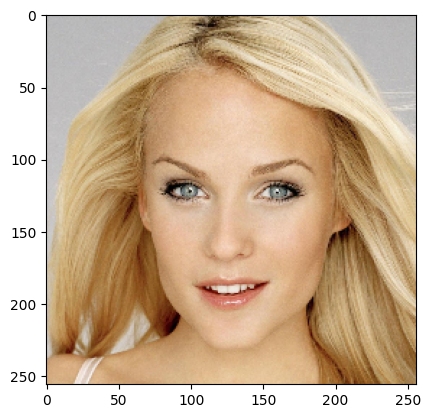

In [79]:
image = cv2.imread("demo.jpg")
image = cv2.imread(os.path.join(root.split('models')[0],"CelebAMask-HQ/CelebA-HQ-img/1.jpg"))
# image = cv2.imread(os.path.join(root.split('models')[0],)"/lustre/fswork/projects/rech/irm/uzq68by/data/CelebAMask-HQ/CelebA-HQ-img/0.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (256, 256))
plt.imshow(image)



In [86]:
image

array([[[185, 185, 187],
        [182, 182, 184],
        [183, 183, 185],
        ...,
        [186, 184, 185],
        [186, 184, 185],
        [187, 185, 186]],

       [[185, 185, 187],
        [185, 185, 187],
        [186, 186, 188],
        ...,
        [183, 181, 182],
        [190, 188, 189],
        [183, 181, 182]],

       [[184, 184, 186],
        [181, 181, 183],
        [184, 184, 186],
        ...,
        [182, 180, 181],
        [182, 180, 181],
        [183, 181, 182]],

       ...,

       [[213, 174, 131],
        [211, 172, 129],
        [209, 170, 127],
        ...,
        [167, 133,  85],
        [165, 132,  86],
        [167, 135,  90]],

       [[209, 170, 127],
        [212, 173, 130],
        [214, 175, 132],
        ...,
        [162, 125,  78],
        [167, 133,  87],
        [169, 136,  91]],

       [[217, 178, 135],
        [213, 174, 131],
        [217, 178, 135],
        ...,
        [156, 117,  70],
        [172, 135,  91],
        [176, 142,  97]]

In [8]:
image_pre, ratio = pose_model.pose_model.preprocess(image)
image_pre.shape

NameError: name 'pose_model' is not defined

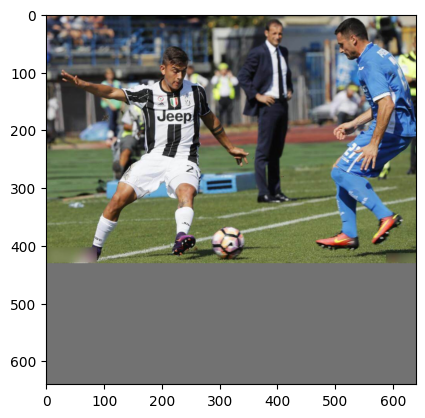

In [31]:
plt.imshow(image_pre)


In [11]:
bboxes = whole.det_model(image)

InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Got invalid dimensions for input: input for the following indices
 index: 2 Got: 640 Expected: 256
 index: 3 Got: 640 Expected: 192
 Please fix either the inputs/outputs or the model.

In [88]:
import torch

In [89]:
image.shape

(256, 256, 3)

In [91]:
keypoints, scores = whole(image)

In [82]:
keypoints.shape

(1, 133, 2)

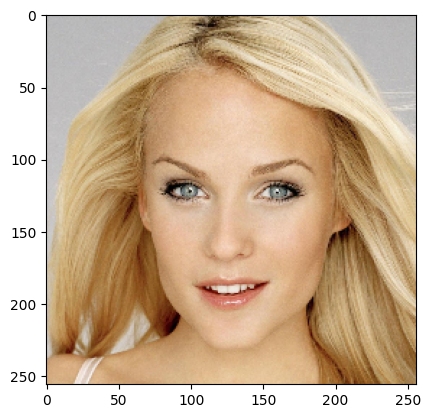

In [83]:
plt.imshow(image)

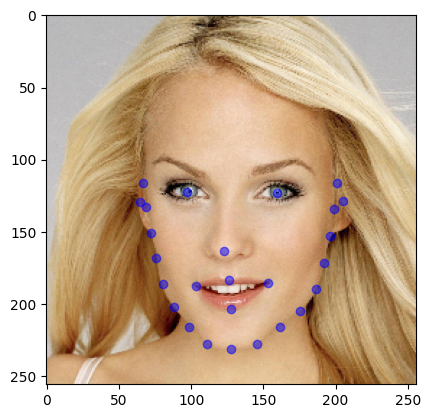

In [84]:
plt.imshow(image)
for i in range(len(keypoints[0])):
    # if i in [0,1,2,3,4,23,24,25,26,27]:
    #     plt.plot(keypoints[0][i][0], keypoints[0][i][1], 'ro', markersize=6)
    if i in [0,1,2,3,4,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,77,71,74,80]:
        plt.plot(keypoints[0][i][0], keypoints[0][i][1], 'bo', markersize=6, alpha=0.5)
    # elif i <=90 and i>=23:
    #     plt.plot(keypoints[0][i][0], keypoints[0][i][1], 'go', markersize=6)


In [15]:
image_keypoints = image.copy()

In [3]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import tqdm

class FFHQDataset(Dataset):
    """
    Dataset for loading images with their corresponding landmark heatmaps.
    """
    def __init__(self, 
                 image_dir,
                 num_samples=70000,
                 image_size=(256, 256)):
        """
        Args:
            image_dir: Directory containing images (e.g., "FlickrFace/images1024x1024")
            num_samples: Total number of samples in dataset
            image_size: Target size for resizing images (H, W)
        """
        self.image_dir = image_dir
        self.num_samples = num_samples
        self.image_size = image_size
        
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Load image (00000.png to 69999.png format)
        image_path = os.path.join(self.image_dir, f"{idx:05d}.png")
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.image_size)
        
        
        return idx, image
    
def collate_fn(batch):
    indices, images = zip(*batch)
    images = np.stack(images, axis=0)
    return np.array(indices), images
    
def convert_to_PIL(x):
    # Convert tensor to PIL image
    x = (x * 255).astype(np.uint8)  # Scale to [0, 255]
    return Image.fromarray(x)

In [30]:
dataset = FFHQDataset(image_dir=os.path.join(root.split('models')[0],"FlickrFace/images1024x1024"),
                     num_samples=70000,
                     image_size=(256, 256))

batch_size = 10
dataset = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_fn)

for idx, batch in tqdm.tqdm(dataset):
    
    for i in range(batch.shape[0]):
        image = batch[i]
        bboxes, keypoints, scores = whole(image)
        # d_eyes = ((keypoints[:,1] - keypoints[:,2])**2).s
        # um(1)**0.5
        # print(d_eyes)
        if len(bboxes) != 0:
            largest_bbox_ind = ((bboxes[:,2]-bboxes[:,0])*(bboxes[:,3]-bboxes[:,1])).argmax()
        else:
            largest_bbox_ind = 0
        ind = largest_bbox_ind
        keypoints = keypoints[ind].reshape(1, -1, 2)
        image_keypoints = np.zeros_like(image)
        print(f"Image {idx[i].item()} done.")
        for j in range(len(keypoints[0])):
            if j in [0,1,2,3,4,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,77,71,74,80]:
                x, y = int(keypoints[0][j][0]),  int(keypoints[0][j][1])
                image_keypoints[y-1:y+2, x-1:x+2, :] = 1
        
        # plt.imshow(image_keypoints * 255)
        img_landmarks = convert_to_PIL(image_keypoints)
        save_path = os.path.join(root.split('models')[0],f"FlickrFace/landmarks_26/{idx[i].item():05d}.png")
        save_image(img_landmarks, save_path)

  0%|          | 0/7000 [00:00<?, ?it/s]

Image 0 done.
Image 1 done.
Image 2 done.
Image 3 done.
Image 4 done.
Image 5 done.
Image 6 done.
Image 7 done.
Image 8 done.


  0%|          | 1/7000 [00:03<7:02:48,  3.62s/it]

Image 9 done.
Image 10 done.
Image 11 done.
Image 12 done.
Image 13 done.
Image 14 done.
Image 15 done.
Image 16 done.
Image 17 done.
Image 18 done.


  0%|          | 1/7000 [00:07<14:40:30,  7.55s/it]


KeyboardInterrupt: 

In [4]:





for i in range(1707, 70000):
    # 00000 to 69999
    # i = 75
    image = cv2.imread(os.path.join(root.split('models')[0],f"FlickrFace/images1024x1024/{i:05d}.png"))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (256, 256))
    # plt.imshow(image)
    # plt.show()
    # break 
    bboxes, keypoints, scores = whole(image)
    # d_eyes = ((keypoints[:,1] - keypoints[:,2])**2).s
    # um(1)**0.5
    # print(d_eyes)
    if len(bboxes) != 0:
        largest_bbox_ind = ((bboxes[:,2]-bboxes[:,0])*(bboxes[:,3]-bboxes[:,1])).argmax()
    else:
        largest_bbox_ind = 0
    ind = largest_bbox_ind
    keypoints = keypoints[ind].reshape(1, -1, 2)
    image_keypoints = np.zeros_like(image)
    print(f"Image {i} done.")
    for j in range(len(keypoints[0])):
        if j in [0,1,2,3,4,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,77,71,74,80]:
            x, y = int(keypoints[0][j][0]),  int(keypoints[0][j][1])
            image_keypoints[y-1:y+2, x-1:x+2, :] = 1
    
    # plt.imshow(image_keypoints * 255)
    img_landmarks = convert_to_PIL(image_keypoints)
    save_path = os.path.join(root.split('models')[0],f"FlickrFace/landmarks_26/{i:05d}.png")
    save_image(img_landmarks, save_path)
    # break

Image 1707 done.
Image 1708 done.
Image 1709 done.
Image 1710 done.
Image 1711 done.
Image 1712 done.
Image 1713 done.
Image 1714 done.
Image 1715 done.
Image 1716 done.
Image 1717 done.
Image 1718 done.
Image 1719 done.
Image 1720 done.
Image 1721 done.
Image 1722 done.
Image 1723 done.
Image 1724 done.
Image 1725 done.
Image 1726 done.
Image 1727 done.
Image 1728 done.
Image 1729 done.
Image 1730 done.
Image 1731 done.
Image 1732 done.
Image 1733 done.
Image 1734 done.
Image 1735 done.
Image 1736 done.
Image 1737 done.
Image 1738 done.
Image 1739 done.
Image 1740 done.
Image 1741 done.
Image 1742 done.
Image 1743 done.
Image 1744 done.
Image 1745 done.
Image 1746 done.
Image 1747 done.
Image 1748 done.
Image 1749 done.
Image 1750 done.
Image 1751 done.
Image 1752 done.
Image 1753 done.
Image 1754 done.
Image 1755 done.
Image 1756 done.
Image 1757 done.
Image 1758 done.
Image 1759 done.
Image 1760 done.
Image 1761 done.
Image 1762 done.
Image 1763 done.
Image 1764 done.
Image 1765 don

In [85]:
len([0,1,2,3,4,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,77,71,74,80])

26

In [10]:
image = draw_skeleton(image,
                            keypoints,
                            scores,
                            openpose_skeleton=openpose_skeleton,
                            kpt_thr=0.3,
                            line_width=2)

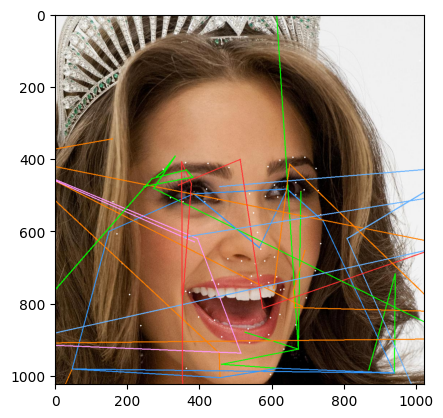

In [11]:
plt.imshow(image)

In [2]:
openpose_skeleton = False  # True for openpose-style, False for mmpose-style

body = Body(
    pose='rtmo',
    to_openpose=openpose_skeleton,
    mode='balanced',  # balanced, performance, lightweight
    backend=backend,
    device=device)

frame_idx = 0

while cap.isOpened():
    success, frame = cap.read()
    frame_idx += 1

    if not success:
        break
    s = time.time()
    keypoints, scores = body(frame)
    det_time = time.time() - s
    print('det: ', det_time)

    img_show = frame.copy()

    # if you want to use black background instead of original image,
    # img_show = np.zeros(img_show.shape, dtype=np.uint8)

    img_show = draw_skeleton(img_show,
                             keypoints,
                             scores,
                             openpose_skeleton=openpose_skeleton,
                             kpt_thr=0.3,
                             line_width=2)

    img_show = cv2.resize(img_show, (960, 640))
    cv2.imshow('img', img_show)
    cv2.waitKey(10)

Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmo/onnx_sdk/rtmo-m_16xb16-600e_body7-640x640-39e78cc4_20231211.zip" to /linkhome/rech/gengcb01/uzq68by/.cache/rtmlib/hub/checkpoints/rtmo-m_16xb16-600e_body7-640x640-39e78cc4_20231211.zip


KeyboardInterrupt: 